In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [5]:
print("Loading dataset...")
df = pd.read_csv('../data/raw/StressSense.csv')

print(f"\n✓ Dataset loaded!")
print(f"Total samples: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

Loading dataset...

✓ Dataset loaded!
Total samples: 495,446
Total columns: 12


In [6]:
print("Column names:")
print(list(df.columns))

print("\nFirst 5 rows:")
df.head()

Column names:
['TimeStamp', 'Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz', 'Mx', 'My', 'Mz', 'User', 'Activity']

First 5 rows:


,TimeStamp,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,User,Activity
0,1.554100e+12,-4.414908,-1.470638,8.139688,-0.553937,0.194943,0.506001,20.10,-28.92,-14.70,1,Eating
1,1.554100e+12,-4.400543,-0.824204,7.292140,-0.387756,0.034088,0.461259,20.22,-28.50,-14.70,1,Eating
2,1.554100e+12,-4.209007,-0.718859,7.407062,-0.469782,-0.055394,0.415453,20.22,-28.08,-14.76,1,Eating
3,1.554100e+12,-4.022259,-0.910395,8.101380,-0.647681,-0.080960,0.383495,20.22,-27.72,-14.82,1,Eating
4,1.554100e+12,-3.892972,-0.685340,8.551490,-0.852212,-0.108657,0.352603,20.22,-27.42,-14.94,1,Eating


In [7]:
print("="*60)
print("ACTIVITY DISTRIBUTION")
print("="*60)

activities = df['Activity'].value_counts()
print(activities)

print(f"\nTotal unique activities: {len(activities)}")

ACTIVITY DISTRIBUTION
Activity
Staying_Still    120063
Nail_Biting      111189
Smoking           94586
Eating            85188
Face_Touch        84420
Name: count, dtype: int64

Total unique activities: 5


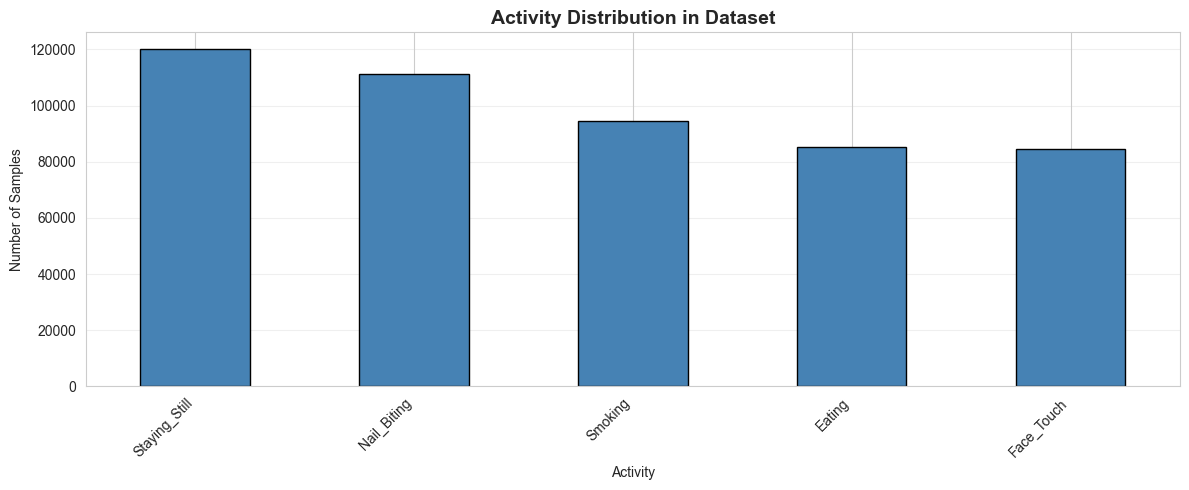

In [8]:
plt.figure(figsize=(12, 5))
activities.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Activity Distribution in Dataset', fontsize=14, weight='bold')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
print("="*60)
print("SAMPLING RATE CALCULATION")
print("="*60)

# Calculate time differences
time_diffs = np.diff(df['TimeStamp'].values)
time_diffs = time_diffs[time_diffs > 0]  # Remove zeros

avg_interval = np.mean(time_diffs)
median_interval = np.median(time_diffs)

# Determine if milliseconds or other unit
if avg_interval > 100:
    sampling_rate = 1000 / avg_interval  # milliseconds
    unit = "milliseconds"
else:
    sampling_rate = 1 / avg_interval  # seconds
    unit = "seconds"

print(f"Average time interval: {avg_interval:.2f} {unit}")
print(f"Median time interval: {median_interval:.2f} {unit}")
print(f"Estimated sampling rate: {sampling_rate:.2f} Hz")

SAMPLING RATE CALCULATION
Average time interval: 777500000.00 milliseconds
Median time interval: 60000000.00 milliseconds
Estimated sampling rate: 0.00 Hz


In [11]:
print("="*60)
print("WRIST SENSOR STATISTICS")
print("="*60)

wrist_cols = ['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz']
sensor_stats = df[wrist_cols].describe()

print(sensor_stats)

WRIST SENSOR STATISTICS
                  Ax             Ay             Az             Gx  \
count  495446.000000  495446.000000  495446.000000  495446.000000   
mean       -1.116050      -2.200025       3.176766      -0.001402   
std         7.514334       3.406115       3.381115       0.462978   
min       -14.415488     -19.048868     -15.783176      -9.031312   
25%        -9.011775      -4.051588       0.947505      -0.098004   
50%        -0.995988      -1.791162       2.350507      -0.001065   
75%         6.383137       0.095170       5.194819       0.099070   
max        19.612701      18.036072      14.516488      13.101687   

                  Gy             Gz  
count  495446.000000  495446.000000  
mean       -0.008364      -0.032532  
std         0.278831       0.499428  
min        -4.984373      -6.003830  
25%        -0.046872      -0.072438  
50%        -0.005326      -0.034088  
75%         0.037284       0.017044  
max         5.070659       5.411543  


In [12]:
print("="*60)
print("USER DISTRIBUTION")
print("="*60)

user_counts = df['User'].value_counts().sort_index()
print(f"Total users: {len(user_counts)}")
print("\nSamples per user:")
print(user_counts)


USER DISTRIBUTION
Total users: 37

Samples per user:
User
1     21427
2     17709
3     16015
4     26475
5     22411
6     20805
7     18776
8     16809
9     19848
10    14329
11    14363
12    17441
13    13848
14    13172
15    17421
16    15777
17    21974
18    17302
19    11175
20     9516
21    11253
22     8443
23    15263
24     9283
25    12137
26    13948
27    12783
28     8816
29     5226
30     9393
31     7671
32     9256
33     5603
34    11202
35     2833
36     2748
37     2995
Name: count, dtype: int64


Plotting Accelerometer data...


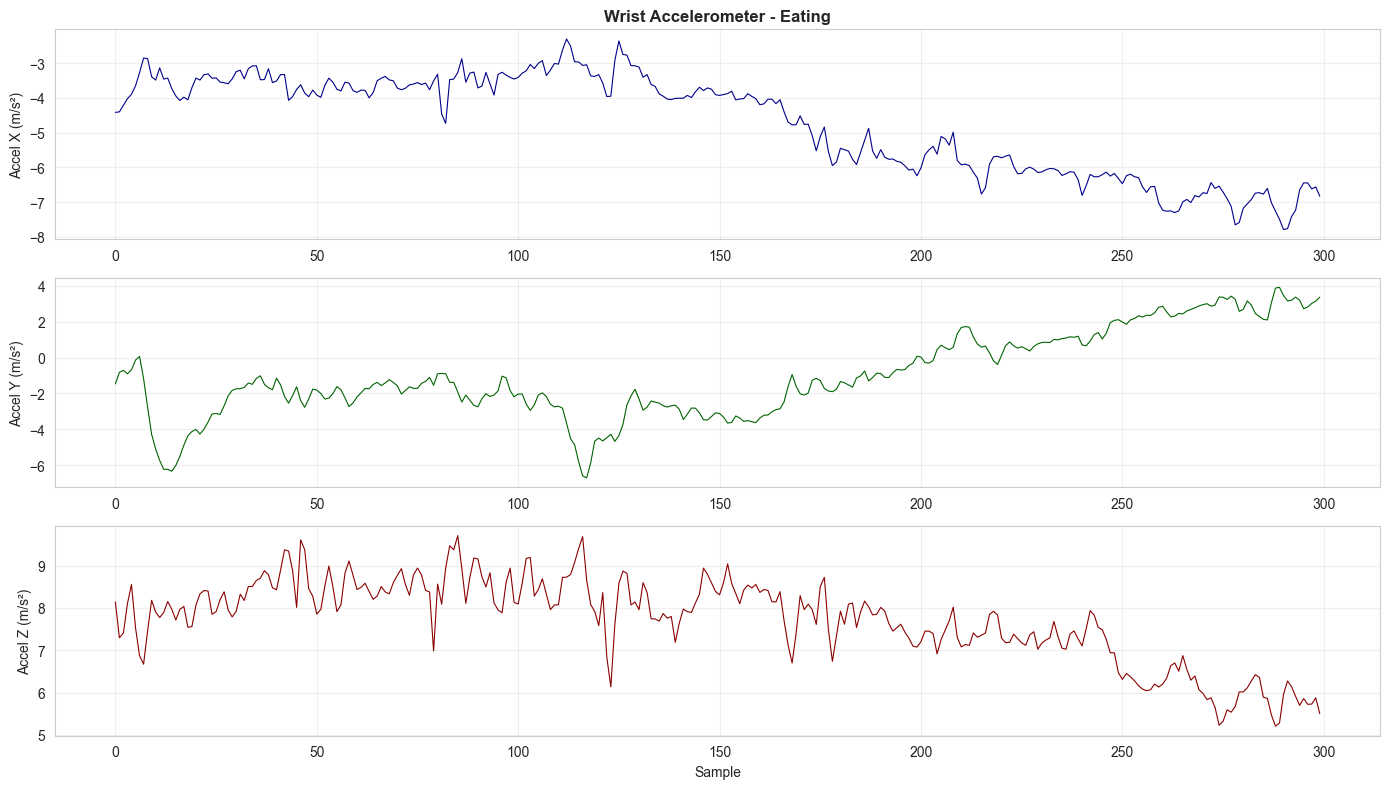

In [13]:
print("Plotting Accelerometer data...")

# Select first activity
first_activity = df['Activity'].iloc[0]
activity_data = df[df['Activity'] == first_activity].head(300)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(activity_data['Ax'].values, color='darkblue', linewidth=0.8)
axes[0].set_ylabel('Accel X (m/s²)')
axes[0].set_title(f'Wrist Accelerometer - {first_activity}', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(activity_data['Ay'].values, color='darkgreen', linewidth=0.8)
axes[1].set_ylabel('Accel Y (m/s²)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(activity_data['Az'].values, color='darkred', linewidth=0.8)
axes[2].set_ylabel('Accel Z (m/s²)')
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting Gyroscope data...


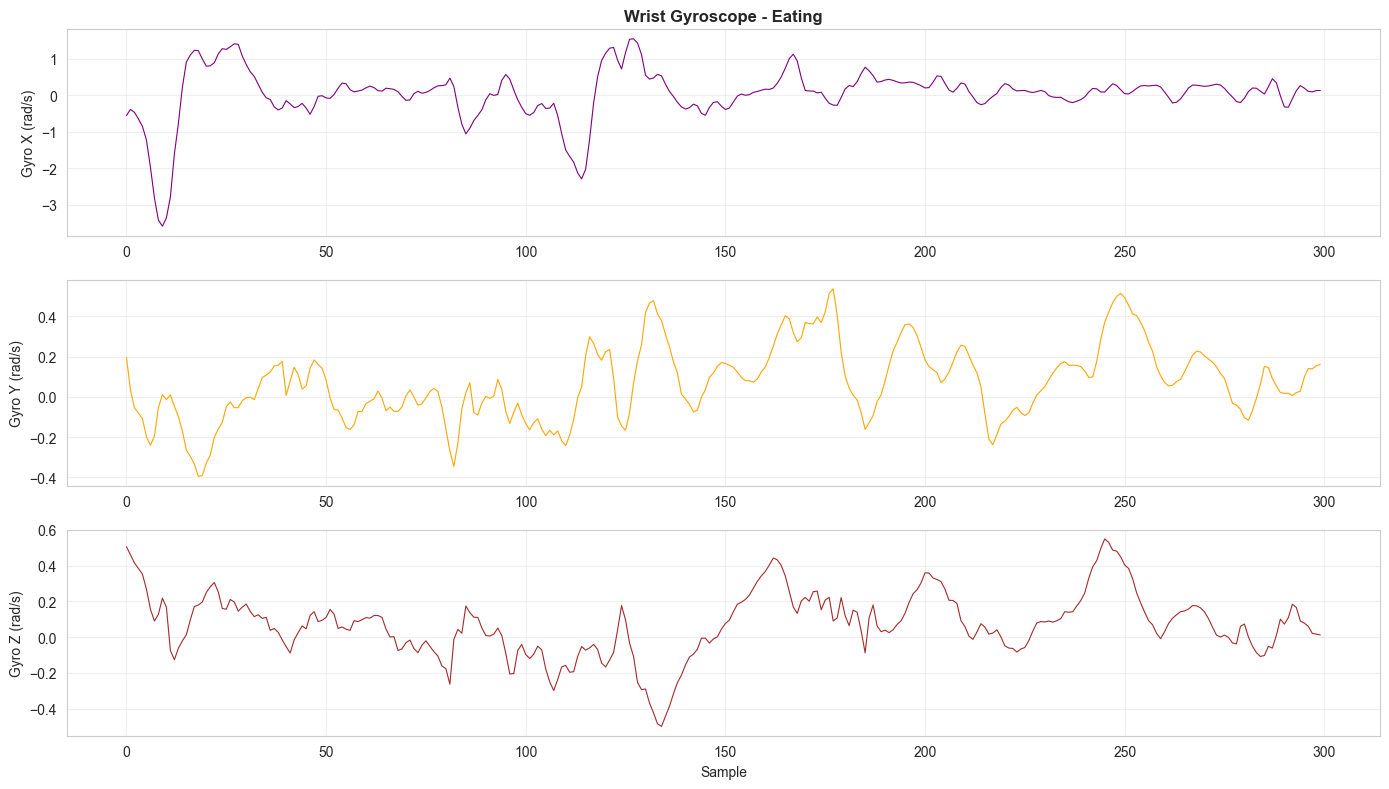

In [14]:
print("Plotting Gyroscope data...")

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(activity_data['Gx'].values, color='purple', linewidth=0.8)
axes[0].set_ylabel('Gyro X (rad/s)')
axes[0].set_title(f'Wrist Gyroscope - {first_activity}', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(activity_data['Gy'].values, color='orange', linewidth=0.8)
axes[1].set_ylabel('Gyro Y (rad/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(activity_data['Gz'].values, color='brown', linewidth=0.8)
axes[2].set_ylabel('Gyro Z (rad/s)')
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing different activities...


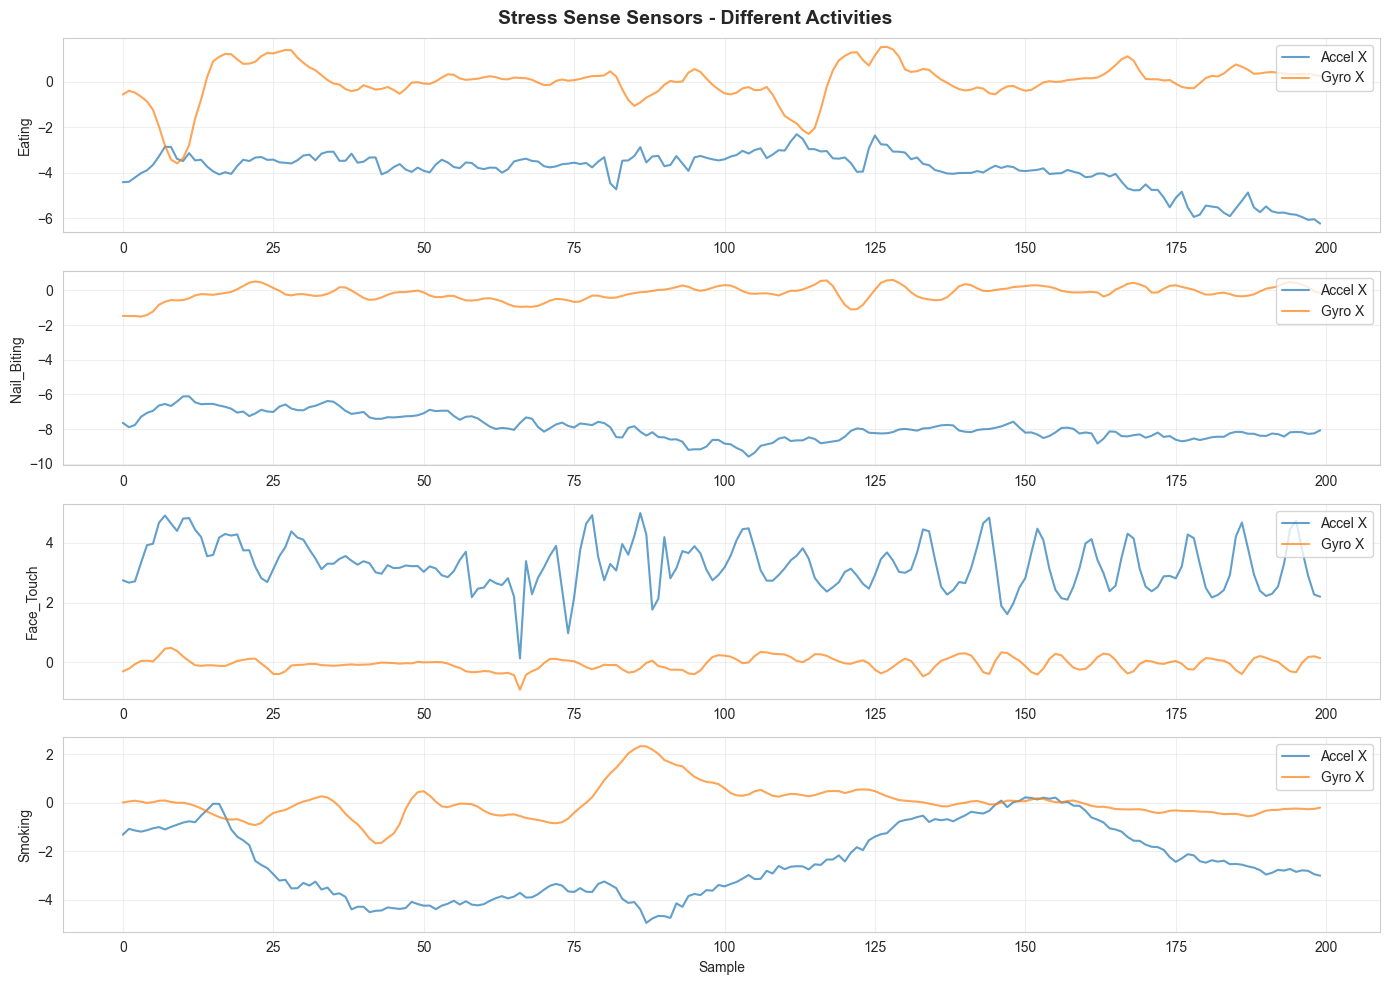

In [15]:
print("Comparing different activities...")

# Select 4 different activities
unique_activities = df['Activity'].unique()[:4]

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

for i, activity in enumerate(unique_activities):
    activity_data = df[df['Activity'] == activity].head(200)
    axes[i].plot(activity_data['Ax'].values, label='Accel X', alpha=0.7)
    axes[i].plot(activity_data['Gx'].values, label='Gyro X', alpha=0.7)
    axes[i].set_ylabel(activity)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Sample')
plt.suptitle('Stress Sense Sensors - Different Activities', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [22]:
print("="*60)
print("SAMPLING RATE ESTIMATION (Timestamps Lost Precision)")
print("="*60)

# Common IMU sampling rates
common_rates = [20, 50, 100, 200]

print("\nAnalyzing data characteristics to estimate sampling rate...\n")

# Get a continuous segment of one activity
first_activity = df['Activity'].iloc[0]
sample_data = df[(df['User'] == 1) & (df['Activity'] == first_activity)].head(500)

if len(sample_data) == 0:
    sample_data = df[df['Activity'] == first_activity].head(500)

print(f"Activity: {first_activity}")
print(f"Sample size: {len(sample_data)}")

# Analyze signal characteristics
ax_values = sample_data['Ax'].values

# Calculate signal characteristics
if len(ax_values) > 1:
    # 1. Look at signal variability
    signal_diff = np.abs(np.diff(ax_values))
    mean_change = signal_diff.mean()
    max_change = signal_diff.max()
    
    print(f"\nSignal Analysis (Ax):")
    print(f"  Mean absolute change: {mean_change:.4f} m/s²")
    print(f"  Max absolute change: {max_change:.4f} m/s²")
    print(f"  Signal range: {ax_values.min():.2f} to {ax_values.max():.2f} m/s²")
    
    # 2. Estimate based on typical human motion
    # Human motion frequency content is typically < 20 Hz
    # Nyquist theorem: need at least 40 Hz sampling (usually 50Hz minimum)
    # Most wearable IMUs use 50-200 Hz
    
    print(f"\n{'='*60}")
    print("MOST LIKELY SAMPLING RATES FOR WEARABLE IMU:")
    print("="*60)
    
    for rate in common_rates:
        window_2s = rate * 2
        window_2_5s = rate * 2.5
        window_3s = rate * 3
        
        print(f"\n{rate} Hz:")
        print(f"  2.0s window = {int(window_2s)} samples")
        print(f"  2.5s window = {int(window_2_5s)} samples")
        print(f"  3.0s window = {int(window_3s)} samples")
    
    print(f"\n{'='*60}")
    print("RECOMMENDATION:")
    print("="*60)
    print("\nBased on typical wearable IMU sensors:")
    print("  • **50 Hz** is most common for activity recognition")
    print("  • 100 Hz is used for more detailed motion analysis")
    print("  • 200 Hz is used for high-frequency motion capture")
    
    print("\n🎯 SUGGESTED: Use 50 Hz as your sampling rate")
    print("   → 2.0s window = 100 samples")
    print("   → 2.5s window = 125 samples")
    print("   → 3.0s window = 150 samples")
    
    # Try to infer from activity duration
    print(f"\n{'='*60}")
    print("VERIFICATION ATTEMPT:")
    print("="*60)
    
    # Count samples per activity instance
    activity_counts = []
    current_activity = None
    current_count = 0
    
    for activity in df['Activity'].head(1000):
        if activity == current_activity:
            current_count += 1
        else:
            if current_count > 0:
                activity_counts.append(current_count)
            current_activity = activity
            current_count = 1
    
    if activity_counts:
        mean_activity_length = np.mean(activity_counts)
        median_activity_length = np.median(activity_counts)
        
        print(f"\nAverage samples per activity segment: {mean_activity_length:.0f}")
        print(f"Median samples per activity segment: {median_activity_length:.0f}")
        
        # If activities are typically 2-5 seconds
        print("\nIf typical activity segments are 2-5 seconds:")
        for rate in common_rates:
            duration_at_rate = mean_activity_length / rate
            print(f"  {rate} Hz → {duration_at_rate:.1f} seconds per segment")
        
        # Most reasonable estimate
        best_rate = 50  # Default assumption
        for rate in common_rates:
            duration = mean_activity_length / rate
            if 2 <= duration <= 10:  # Reasonable activity duration
                best_rate = rate
                break
        
        print(f"\n✅ BEST ESTIMATE: {best_rate} Hz")
        print(f"   (Based on {mean_activity_length:.0f} samples ≈ {mean_activity_length/best_rate:.1f} seconds)")

else:
    print("ERROR: Not enough data!")

print("\n" + "="*60)

SAMPLING RATE ESTIMATION (Timestamps Lost Precision)

Analyzing data characteristics to estimate sampling rate...

Activity: Smoking
Sample size: 500

Signal Analysis (Ax):
  Mean absolute change: 0.5489 m/s²
  Max absolute change: 18.4832 m/s²
  Signal range: -9.97 to 19.61 m/s²

MOST LIKELY SAMPLING RATES FOR WEARABLE IMU:

20 Hz:
  2.0s window = 40 samples
  2.5s window = 50 samples
  3.0s window = 60 samples

50 Hz:
  2.0s window = 100 samples
  2.5s window = 125 samples
  3.0s window = 150 samples

100 Hz:
  2.0s window = 200 samples
  2.5s window = 250 samples
  3.0s window = 300 samples

200 Hz:
  2.0s window = 400 samples
  2.5s window = 500 samples
  3.0s window = 600 samples

RECOMMENDATION:

Based on typical wearable IMU sensors:
  • **50 Hz** is most common for activity recognition
  • 100 Hz is used for more detailed motion analysis
  • 200 Hz is used for high-frequency motion capture

🎯 SUGGESTED: Use 50 Hz as your sampling rate
   → 2.0s window = 100 samples
   → 2.5s wi